# Анализ входных данных train_data.csv и questions.csv

## Что делает этот блокнот:
1. **Загружает и проверяет** структуру двух датасетов:
   - `train_data.csv` — тексты базы знаний;
   - `questions.csv` — тестовый набор вопросов для RAG;

2. **Анализирует базовые статистики**:
   - Длину текстов статей;
   - Длину вопросов;
   - Наличие пропусков, дубликатов;

3. **Исследует качество теговой разметки**:
   - Сравнивает теги с топ-словами статей;
   - Выявляет частотность тегов;

4. **Анализирует лексическое покрытие**:
   - Находит пересечение между словами вопросов, тегами и контентом статей;
   - Строит корреляционные матрицы слов по тегам.

## Общий обзор

In [64]:
pip install nltk torch

Note: you may need to restart the kernel to use updated packages.


In [45]:
import pandas as pd
import numpy as np

import random

import torch

import re
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [46]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("DEVICE:", DEVICE)

DEVICE: cpu


In [50]:
train_path = '../data/train_data.csv'
questions_path = '../data/questions.csv'

train = pd.read_csv(train_path)
questions = pd.read_csv(questions_path)

In [18]:
train.info()
train.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          350 non-null    object
 1   annotation  346 non-null    object
 2   tags        350 non-null    object
 3   text        350 non-null    object
dtypes: object(4)
memory usage: 11.1+ KB


,id,annotation,tags,text
0,doc_001,Светлана из Казани дает частные уроки английск...,"['Начать бизнес', 'Самозанятые', 'Свое дело', ...",## Кто такой самозанятый?\n\nПо закону самозан...
1,doc_002,"Елене назначили социальное пособие на ребенка,...","['Защитить права', 'Банки', 'Банковская карта'...",Первым делом нужно попросить банк проверить ма...
2,doc_003,Самый надежный способ не оказаться в долгах — ...,"['Кредиты', 'Долги', 'Просрочки', 'Ипотека', '...",## Не переоценивайте свои финансовые возможнос...
3,doc_004,"Друзья Александра то и дело хвастаются, что по...","['Инвестиции', 'Ценные бумаги', 'Фондовая бирж...",Просто прийти на биржу и купить ценные бумаги ...
4,doc_005,Вы взяли в микрофинансовой организации заем на...,"['Займы', 'Долги', 'Риски', 'Защитить права']","## МФО больше нет в госреестре. Значит, она за..."


In [19]:
#  1   annotation  346 non-null    object
# В столбце annotation есть нулевые значения

null_rows = train[train.isnull().any(axis=1)]

print(f'Количество строк с пропущенными значениями: {len(null_rows)}')
print('\nСтроки с пропущенными значениями:')
null_rows

Количество строк с пропущенными значениями: 4

Строки с пропущенными значениями:


,id,annotation,tags,text
104,doc_105,NaN,"['Финансы для детей', 'Финансовые цели', 'План...",## Почему важно говорить с детьми о финансах?\...
172,doc_173,NaN,"['Лайфхаки', 'Планирование', 'Финансовые цели'...",## Открыть депозит\n\nНовогодняя суета отнимае...
231,doc_232,NaN,"['Ипотека', 'Финансовые решения', 'Риски']",## Что такое долевое строительство?\n\nКвартир...
332,doc_333,NaN,"['Начать бизнес', 'Привлечь деньги', 'Свое дел...",Весь процесс краудфандинга можно разбить на не...


In [20]:
questions.info()
questions.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID вопроса  500 non-null    int64 
 1   Вопрос      500 non-null    object
dtypes: int64(1), object(1)
memory usage: 7.9+ KB


,ID вопроса,Вопрос
0,1,Как просрочка по «беспроцентному» займу скажет...
1,2,"Как действовать вкладчику при отзыве лицензии,..."
2,3,Как действовать при оспаривании незаконной про...
3,4,Как изменился лимит социального вычета на спор...
4,5,Чем отличаются сроки обращения за наследством ...


In [49]:
# Проверка дубликатов
exact_duplicates_text = train[train['text'].duplicated(keep=False)]
print(f"Кол-во статей-дубликатов: {len(exact_duplicates_text)}")

exact_duplicates_questions = questions[questions['Вопрос'].duplicated(keep=False)]
print(f"Кол-во вопросов-дубликатов: {len(exact_duplicates_questions)}")

Кол-во статей-дубликатов: 0
Кол-во вопросов-дубликатов: 2


In [48]:
for q in exact_duplicates_questions['Вопрос'].unique():
    ids = exact_duplicates_questions[exact_duplicates_questions['Вопрос'] == q]['ID вопроса'].tolist()
    print(f"{q} - ID: {ids}")

Чем для вкладчика отличается санация от отзыва лицензии? - ID: [18, 134]


In [4]:
questions = questions.drop_duplicates(subset=['Вопрос'])

### Статистика

In [5]:
train['text_length'] = train['text'].astype(str).apply(len)
train['word_count'] = train['text'].astype(str).apply(lambda x: len(x.split()))

print('Средняя длина текста (символы):', train['text_length'].mean())
print('Средняя длина текста (слова):', train['word_count'].mean())
print('Минимальная / максимальная длина:', train['word_count'].min(), '/', train['word_count'].max(), '\n')


Средняя длина текста (символы): 9026.594285714285
Средняя длина текста (слова): 1307.2685714285715
Минимальная / максимальная длина: 287 / 3570 



In [6]:
questions['text_length'] = questions['Вопрос'].astype(str).apply(len)
questions['word_count'] = questions['Вопрос'].astype(str).apply(lambda x: len(x.split()))
print('Количество вопросов:', len(questions))
print('Средняя длина вопроса (в символах):', questions['text_length'].mean())
print('Средняя длина вопроса (в словах):', questions['word_count'].mean())
print('Примеры длинных вопросов:')
print(questions.sort_values(by='word_count', ascending=False).head(5)[['ID вопроса', 'Вопрос']])

Количество вопросов: 499
Средняя длина вопроса (в символах): 78.71943887775551
Средняя длина вопроса (в словах): 10.969939879759519
Примеры длинных вопросов:
     ID вопроса                                             Вопрос
223         224  Каков минимальный срок «периода охлаждения» дл...
337         338  Что произойдет с вашими деньгами при отзыве ли...
41           42  Как меняется роль Банка России в защите интере...
238         239  Куда подавать заявку на продажу заблокированны...
295         296  Обязателен ли для продавцов прием платежей по ...


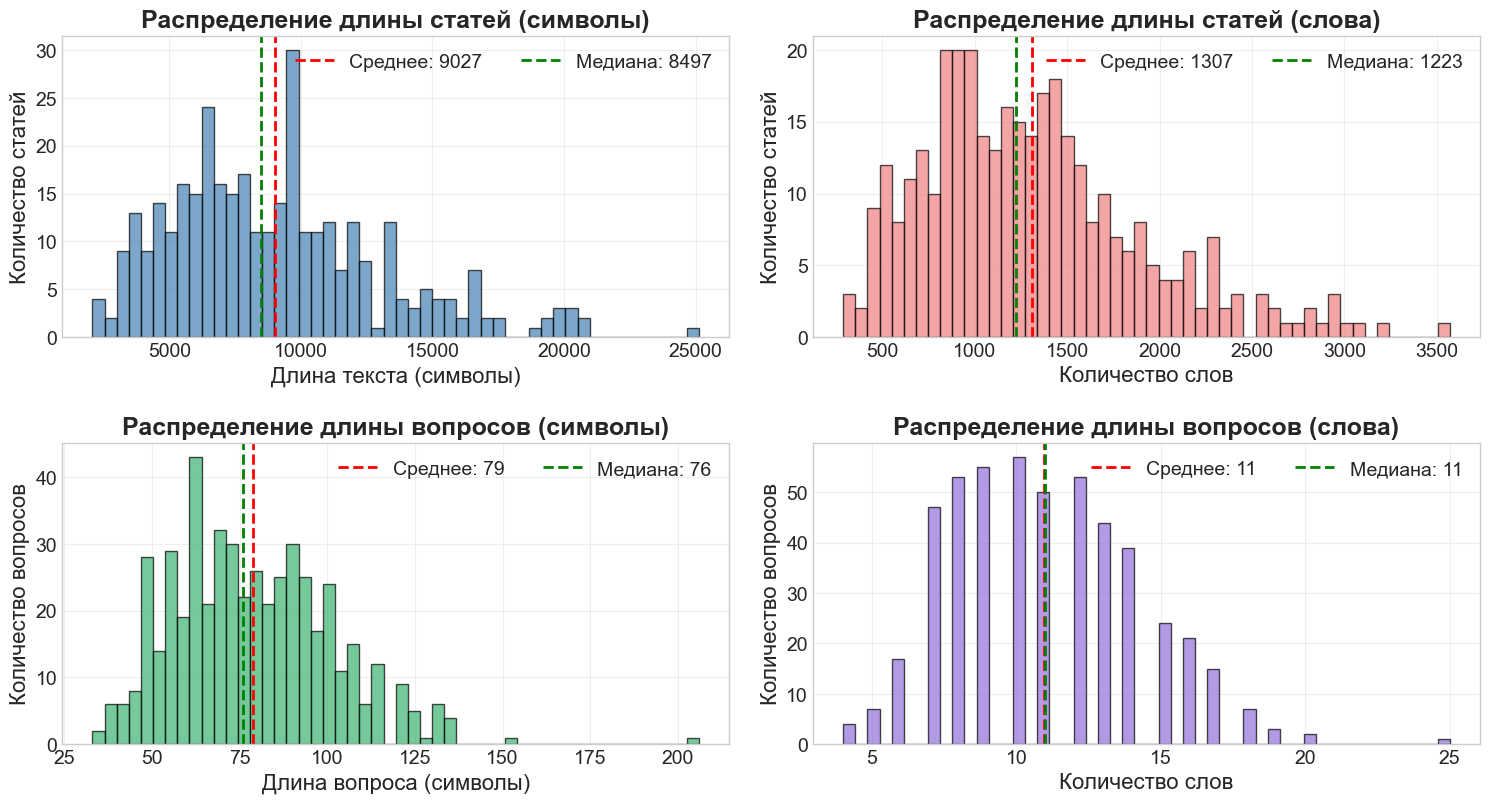

In [44]:
# Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Создаем фигуру с четырьмя подграфиками
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Гистограмма распределения длины статей (в символах)
axes[0, 0].hist(train['text_length'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_title('Распределение длины статей (символы)', fontsize=18, fontweight='bold')
axes[0, 0].set_xlabel('Длина текста (символы)', fontsize=16)
axes[0, 0].set_ylabel('Количество статей', fontsize=16)
axes[0, 0].tick_params(axis='both', labelsize=14)
axes[0, 0].axvline(train['text_length'].mean(), color='red', linestyle='--', linewidth=2, 
                   label=f'Среднее: {train["text_length"].mean():.0f}')
axes[0, 0].axvline(train['text_length'].median(), color='green', linestyle='--', linewidth=2, 
                   label=f'Медиана: {train["text_length"].median():.0f}')
axes[0, 0].legend(fontsize=14, ncol=2)
axes[0, 0].grid(True, alpha=0.3)

# 2. Гистограмма распределения длины статей (в словах)
axes[0, 1].hist(train['word_count'], bins=50, edgecolor='black', alpha=0.7, color='lightcoral')
axes[0, 1].set_title('Распределение длины статей (слова)', fontsize=18, fontweight='bold')
axes[0, 1].set_xlabel('Количество слов', fontsize=16)
axes[0, 1].set_ylabel('Количество статей', fontsize=16)
axes[0, 1].tick_params(axis='both', labelsize=14)
axes[0, 1].axvline(train['word_count'].mean(), color='red', linestyle='--', linewidth=2, 
                   label=f'Среднее: {train["word_count"].mean():.0f}')
axes[0, 1].axvline(train['word_count'].median(), color='green', linestyle='--', linewidth=2, 
                   label=f'Медиана: {train["word_count"].median():.0f}')
axes[0, 1].legend(fontsize=14, ncol=2)
axes[0, 1].grid(True, alpha=0.3)

# 3. Гистограмма распределения длины вопросов (в символах)
axes[1, 0].hist(questions['text_length'], bins=50, edgecolor='black', alpha=0.7, color='mediumseagreen')
axes[1, 0].set_title('Распределение длины вопросов (символы)', fontsize=18, fontweight='bold')
axes[1, 0].set_xlabel('Длина вопроса (символы)', fontsize=16)
axes[1, 0].set_ylabel('Количество вопросов', fontsize=16)
axes[1, 0].tick_params(axis='both', labelsize=14)
axes[1, 0].axvline(questions['text_length'].mean(), color='red', linestyle='--', linewidth=2, 
                   label=f'Среднее: {questions["text_length"].mean():.0f}')
axes[1, 0].axvline(questions['text_length'].median(), color='green', linestyle='--', linewidth=2, 
                   label=f'Медиана: {questions["text_length"].median():.0f}')
axes[1, 0].legend(fontsize=14, ncol=2)
axes[1, 0].grid(True, alpha=0.3)

# 4. Гистограмма распределения длины вопросов (в словах)
axes[1, 1].hist(questions['word_count'], bins=50, edgecolor='black', alpha=0.7, color='mediumpurple')
axes[1, 1].set_title('Распределение длины вопросов (слова)', fontsize=18, fontweight='bold')
axes[1, 1].set_xlabel('Количество слов', fontsize=16)
axes[1, 1].set_ylabel('Количество вопросов', fontsize=16)
axes[1, 1].tick_params(axis='both', labelsize=14)
axes[1, 1].axvline(questions['word_count'].mean(), color='red', linestyle='--', linewidth=2, 
                   label=f'Среднее: {questions["word_count"].mean():.0f}')
axes[1, 1].axvline(questions['word_count'].median(), color='green', linestyle='--', linewidth=2, 
                   label=f'Медиана: {questions["word_count"].median():.0f}')
axes[1, 1].legend(fontsize=14, ncol=2)
axes[1, 1].grid(True, alpha=0.3)

# # Добавляем статистику на график - левый блок
# stats_text_left = f"""Статьи (символы):
# Среднее: {train['text_length'].mean():.1f}
# Медиана: {train['text_length'].median():.1f}
# Мин/Макс: {train['text_length'].min()}/{train['text_length'].max()}

# Статьи (слова):
# Среднее: {train['word_count'].mean():.1f}
# Медиана: {train['word_count'].median():.1f}
# Мин/Макс: {train['word_count'].min()}/{train['word_count'].max()}"""

# # Добавляем статистику на график - правый блок
# stats_text_right = f"""Вопросы (символы):
# Среднее: {questions['text_length'].mean():.1f}
# Медиана: {questions['text_length'].median():.1f}
# Мин/Макс: {questions['text_length'].min()}/{questions['text_length'].max()}

# Вопросы (слова):
# Среднее: {questions['word_count'].mean():.1f}
# Медиана: {questions['word_count'].median():.1f}
# Мин/Макс: {questions['word_count'].min()}/{questions['word_count'].max()}"""

# plt.figtext(0.02, -0.01, stats_text_left, fontsize=14, fontfamily='monospace', 
#             bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.8))

# plt.figtext(0.20, -0.01, stats_text_right, fontsize=14, fontfamily='monospace', 
#             bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.subplots_adjust(bottom=0.25, hspace=0.35)
plt.show()

## Проверка гипотез

### Маркдаун символы

В тексте статей присутствуют markdown-символы. Возможно, можно сделать из заголовков, жирного или курсивного текста метаданные.

In [23]:
def count_markdown_symbols(text):
    return len(re.findall(r'(\*\*|##|`|__|[_*#-]{2,})', str(text)))

In [24]:
train['markdown_count'] = train['text'].apply(count_markdown_symbols)
print('Среднее количество markdown-разметки в статье:', train['markdown_count'].mean())
print('Доля статей с разметкой:', (train['markdown_count'] > 0).mean())


Среднее количество markdown-разметки в статье: 20.945714285714285
Доля статей с разметкой: 0.9971428571428571


In [25]:
no_md = train[train['markdown_count'] == 0]
no_md

,id,annotation,tags,text,text_length,word_count,markdown_count
86,doc_087,"Последние модели смартфонов, новые коллекции м...",['Мошенничество'],Из-за санкций многие товары перестали официаль...,3817,547,0


Практически во всех статьях есть маркдаун символы.

In [50]:
# Анализ маркдаун структуры

def count_markdown_headers(text):
    text = str(text)
    h1 = len(re.findall(r'^#\s+', text, re.MULTILINE))
    h2 = len(re.findall(r'^##\s+', text, re.MULTILINE))
    h3 = len(re.findall(r'^###\s+', text, re.MULTILINE))
    h4 = len(re.findall(r'^####\s+', text, re.MULTILINE))
    return h1, h2, h3, h4

def count_lists(text):
    text = str(text)
    # Маркированные списки: -, *, + в начале строки
    bullet_lists = len(re.findall(r'^[\*\+\-]\s+', text, re.MULTILINE))
    # Нумерованные списки: 1., 2., 10. и т.д.
    numbered_lists = len(re.findall(r'^\d+\.\s+', text, re.MULTILINE))
    return bullet_lists, numbered_lists

def count_tables(text):
    text = str(text)
    table_rows = 0
    lines = text.split('\n')
    in_table = False
    for line in lines:
        if '|' in line and not re.match(r'^[\s\|:\-]+$', line):
            table_rows += 1
            in_table = True
        elif in_table and not line.strip():
            break
    # Количество таблиц = количество строк с разделителями (|---|)
    table_sep = len(re.findall(r'^\|[\s\-:|]+\|$', text, re.MULTILINE))
    return table_sep, table_rows

def count_markdown_links(text):
    text = str(text)
    links = len(re.findall(r'\[([^\]]+)\]\(([^\)]+)\)', text))
    return links

def count_bold_italic(text):
    text = str(text)
    bold = len(re.findall(r'\*\*([^\*]+)\*\*', text)) + len(re.findall(r'__([^_]+)__', text))
    italic = len(re.findall(r'\*([^\*]+)\*', text)) + len(re.findall(r'_([^_]+)_', text))
    return bold, italic

In [51]:
train['h1_count'] = 0
train['h2_count'] = 0
train['h3_count'] = 0
train['h4_count'] = 0
train['bullet_lists'] = 0
train['numbered_lists'] = 0
train['tables_count'] = 0
train['table_rows'] = 0
train['code_blocks'] = 0
train['links'] = 0
train['images'] = 0
train['bold_count'] = 0
train['italic_count'] = 0

for idx, row in train.iterrows():
    text = row['text']
    
    h1, h2, h3, h4 = count_markdown_headers(text)
    train.at[idx, 'h1_count'] = h1
    train.at[idx, 'h2_count'] = h2
    train.at[idx, 'h3_count'] = h3
    train.at[idx, 'h4_count'] = h4
    
    bullet, numbered = count_lists(text)
    train.at[idx, 'bullet_lists'] = bullet
    train.at[idx, 'numbered_lists'] = numbered
    
    tables, rows = count_tables(text)
    train.at[idx, 'tables_count'] = tables
    train.at[idx, 'table_rows'] = rows
    
    train.at[idx, 'links'] = count_markdown_links(text)
    
    bold, italic = count_bold_italic(text)
    train.at[idx, 'bold_count'] = bold
    train.at[idx, 'italic_count'] = italic

In [57]:
print(f"Всего статей: {len(train)}")
print(f"Статей с заголовками: {(train[['h1_count','h2_count','h3_count']].sum(axis=1) > 0).sum()} ({((train[['h1_count','h2_count','h3_count']].sum(axis=1) > 0).sum()/len(train))*100:.1f}%)")
print(f"Статей со списками: {((train['bullet_lists'] + train['numbered_lists']) > 0).sum()} ({((train['bullet_lists'] + train['numbered_lists'] > 0).sum()/len(train))*100:.1f}%)")
print(f"Статей с таблицами: {(train['tables_count'] > 0).sum()} ({(train['tables_count'] > 0).sum()/len(train)*100:.1f}%)")
print(f"Статей со ссылками: {(train['links'] > 0).sum()} ({(train['links'] > 0).sum()/len(train)*100:.1f}%)")

print("\nСредние значения на статью:")
print(f"Заголовков H1: {train['h1_count'].mean():.2f}")
print(f"Заголовков H2: {train['h2_count'].mean():.2f}")
print(f"Заголовков H3: {train['h3_count'].mean():.2f}")
print(f"Маркированных списков: {train['bullet_lists'].mean():.2f}")
print(f"Нумерованных списков: {train['numbered_lists'].mean():.2f}")
print(f"Таблиц: {train['tables_count'].mean():.2f}")
print(f"Ссылок: {train['links'].mean():.2f}")
print(f"Жирного текста: {train['bold_count'].mean():.2f}")
print(f"Курсива: {train['italic_count'].mean():.2f}")

Всего статей: 350
Статей с заголовками: 347 (99.1%)
Статей со списками: 255 (72.9%)
Статей с таблицами: 0 (0.0%)
Статей со ссылками: 0 (0.0%)

Средние значения на статью:
Заголовков H1: 0.00
Заголовков H2: 5.79
Заголовков H3: 2.21
Маркированных списков: 5.58
Нумерованных списков: 1.46
Таблиц: 0.00
Ссылок: 0.00
Жирного текста: 6.40
Курсива: 14.40


### Взаимосвязь между тегами и содержанием статей

Сравнение тегов и самых часто встречающихся слов в статьях. Проверка, релевантны ли теги

In [9]:
stop_words = set(stopwords.words('russian'))

def clean_tag_list(tag_str):
    # Извлекает список тегов из строки
    try:
        return re.findall(r"'([^']+)'", tag_str)
    except:
        return []

def get_top_words(text, n=10):
    # Возвращает самые частые значимые слов из текста кол-вом как и теги
    words = word_tokenize(re.sub(r'[^А-Яа-яA-Za-z]', ' ', str(text)).lower())
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return [w for w, _ in Counter(words).most_common(n)]

def tag_overlap_score(row):
    # Считает долю совпадений между тегами и топ-словами той же длины
    tags = [t.lower() for t in row['tag_list']]
    if len(tags) == 0:
        return 0.0, []
    top_words = set(get_top_words(row['text'], n=len(tags)))
    tags_set = set(tags)
    overlap = top_words & tags_set
    return len(overlap) / len(tags_set), list(overlap)


In [10]:
train['tag_list'] = train['tags'].apply(clean_tag_list)

# Подсчёт совпадений
train[['tag_overlap_score', 'matched_tags']] = train.apply(
    lambda row: pd.Series(tag_overlap_score(row)), axis=1
)


Статистика совпадений тегов и топ-слов
Средний процент совпадений: 2.09%
Медианный процент совпадений: 0.00%
Статей с хотя бы одним совпадением: 8.57%

Примеры с наибольшим совпадением:


,annotation,tag_list,matched_tags
96,Павел купил свою первую машину с рук и сразу ж...,"[Мошенничество, Страховки, Автострахование, ОС...","[страховки, осаго]"
49,С 1 марта 2025 года можно настроить самозапрет...,"[Кредиты, Займы, Кредитная история]",[кредиты]
72,Сергей чуть не пропустил покупку очередной стр...,"[Автострахование, ОСАГО, Страховки]",[осаго]
128,Андрей пытался оформить ОСАГО на сайте страхов...,"[Автострахование, ОСАГО, Страховки]",[осаго]
201,"Если цены постоянно растут — значит, в стране ...","[Инфляция, Семейный бюджет, Планирование]",[инфляция]



Примеры с наименьшим совпадением:


,annotation,tag_list,matched_tags
0,Светлана из Казани дает частные уроки английск...,"[Начать бизнес, Самозанятые, Свое дело, Налоги]",[]
1,"Елене назначили социальное пособие на ребенка,...","[Защитить права, Банки, Банковская карта, Риск...",[]
2,Самый надежный способ не оказаться в долгах — ...,"[Кредиты, Долги, Просрочки, Ипотека, Кредитная...",[]
3,"Друзья Александра то и дело хвастаются, что по...","[Инвестиции, Ценные бумаги, Фондовая биржа, Ак...",[]
5,"Продолжаем рассказывать о книгах, которые реко...",[Что читают в ЦБ],[]


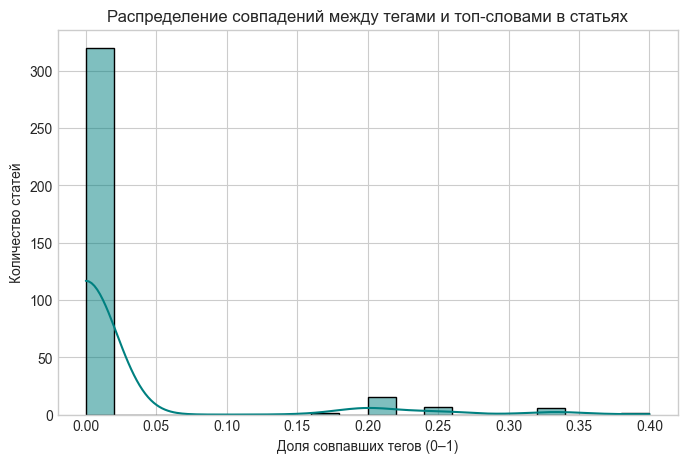

In [11]:
# Статистика
print('\nСтатистика совпадений тегов и топ-слов')
print(f"Средний процент совпадений: {train['tag_overlap_score'].mean() * 100:.2f}%")
print(f"Медианный процент совпадений: {train['tag_overlap_score'].median() * 100:.2f}%")
print(f"Статей с хотя бы одним совпадением: {(train['tag_overlap_score'] > 0).mean() * 100:.2f}%")

print('\nПримеры с наибольшим совпадением:')
display(train.nlargest(5, 'tag_overlap_score')[['annotation', 'tag_list', 'matched_tags']])

print('\nПримеры с наименьшим совпадением:')
display(train.nsmallest(5, 'tag_overlap_score')[['annotation', 'tag_list', 'matched_tags']])

plt.figure(figsize=(8, 5))
sns.histplot(train['tag_overlap_score'], bins=20, kde=True, color='teal')
plt.title('Распределение совпадений между тегами и топ-словами в статьях')
plt.xlabel('Доля совпавших тегов (0–1)')
plt.ylabel('Количество статей')
plt.show()


In [12]:
train['tag_list'] = train['tags'].apply(clean_tag_list)
all_tags = [tag for tags in train['tag_list'] for tag in tags]
tag_freq = Counter(all_tags)
print('Топ-20 тегов\n')
for tag, count in tag_freq.most_common(20):
    print(f'{tag}: {count}')

Топ-20 тегов

Риски: 106
Банковские услуги: 75
Кредиты: 68
Мошенничество: 59
Планирование: 57
Инвестиции: 48
Долги: 47
Займы: 46
Безналичные платежи: 43
Страховки: 43
Как выбрать: 42
Банковская карта: 41
Защитить права: 40
Семейный бюджет: 35
Ценные бумаги: 33
Украли деньги: 33
Свое дело: 31
Финансовые цели: 29
Накопить: 29
Просрочки: 26


In [13]:
def get_keywords(text, n=20):
    words = word_tokenize(re.sub(r'[^А-Яа-яA-Za-z]', ' ', str(text)).lower())
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return Counter(words).most_common(n)

sample_texts = train.sample(350, random_state=42)
top_words = Counter()
for txt in sample_texts['text']:
    top_words.update(dict(get_keywords(txt, 50)))

print('Топ-20 часто встречающихся слов\n')
for w, c in top_words.most_common(20):
    print(f'{w}: {c}')

Топ-20 часто встречающихся слов

деньги: 2364
это: 1807
банк: 1433
например: 1336
рублей: 1189
которые: 1045
нужно: 1017
банка: 950
могут: 843
компании: 736
счет: 698
кредит: 585
мфо: 574
карты: 547
денег: 533
договор: 530
случае: 506
получить: 463
россии: 460
счета: 458


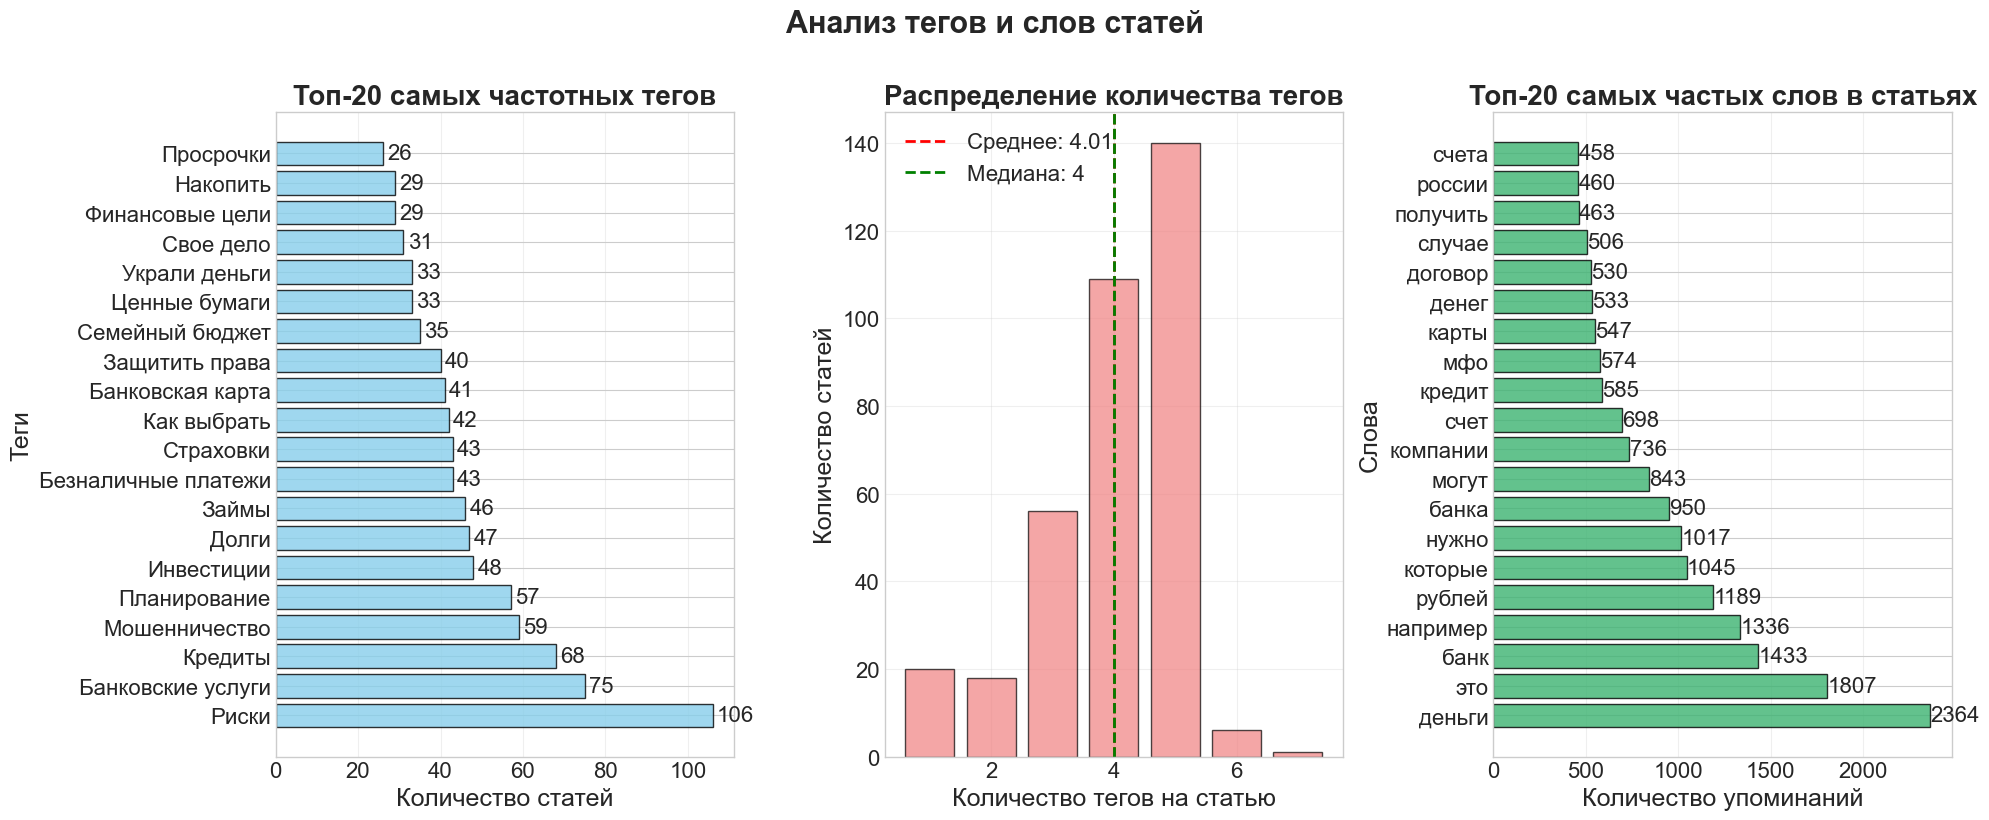

СТАТИСТИКА ПО ТЕГАМ И СЛОВАМ

Всего уникальных тегов: 57
Среднее тегов на статью: 4.01
Медиана тегов на статью: 4
Мин/Макс тегов на статью: 1/7

Всего уникальных слов (в выборке): 4128
Всего упоминаний слов (в выборке): 86924
Среднее упоминаний на слово: 21.06

Топ-5 тегов:
1. Риски: 106 статей
2. Банковские услуги: 75 статей
3. Кредиты: 68 статей
4. Мошенничество: 59 статей
5. Планирование: 57 статей

Топ-5 слов:
1. деньги: 2364 упоминаний
2. это: 1807 упоминаний
3. банк: 1433 упоминаний
4. например: 1336 упоминаний
5. рублей: 1189 упоминаний


In [27]:
# Три графика в ряд с дополнительной статистикой
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# 1. Топ-20 тегов (горизонтальная гистограмма)
top_tags = tag_freq.most_common(20)
tags, counts = zip(*top_tags)

bars = axes[0].barh(tags, counts, color='skyblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Топ-20 самых частотных тегов', fontsize=20, fontweight='bold')
axes[0].set_xlabel('Количество статей', fontsize=18)
axes[0].set_ylabel('Теги', fontsize=18)
axes[0].tick_params(axis='both', labelsize=16)
axes[0].grid(True, alpha=0.3, axis='x')

for i, (bar, count) in enumerate(zip(bars, counts)):
    axes[0].text(count + 1, bar.get_y() + bar.get_height()/2, 
                f'{count}', va='center', fontsize=16)

# 2. Распределение количества тегов на статью
train['tag_count'] = train['tag_list'].apply(len)
tag_count_dist = train['tag_count'].value_counts().sort_index()

axes[1].bar(tag_count_dist.index, tag_count_dist.values, edgecolor='black', alpha=0.7, color='lightcoral')
axes[1].set_title('Распределение количества тегов', fontsize=20, fontweight='bold')
axes[1].set_xlabel('Количество тегов на статью', fontsize=18)
axes[1].set_ylabel('Количество статей', fontsize=18)
axes[1].tick_params(axis='both', labelsize=16)
axes[1].axvline(train['tag_count'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Среднее: {train["tag_count"].mean():.2f}')
axes[1].axvline(train['tag_count'].median(), color='green', linestyle='--', linewidth=2, 
                label=f'Медиана: {train["tag_count"].median():.0f}')
axes[1].legend(fontsize=16)
axes[1].grid(True, alpha=0.3)

# 3. Топ-20 самых частых слов в статьях (горизонтальная гистограмма)
top_words_list = top_words.most_common(20)
words, word_counts = zip(*top_words_list)

bars = axes[2].barh(words, word_counts, color='mediumseagreen', edgecolor='black', alpha=0.8)
axes[2].set_title('Топ-20 самых частых слов в статьях', fontsize=20, fontweight='bold')
axes[2].set_xlabel('Количество упоминаний', fontsize=18)
axes[2].set_ylabel('Слова', fontsize=18)
axes[2].tick_params(axis='both', labelsize=16)
axes[2].grid(True, alpha=0.3, axis='x')

for i, (bar, count) in enumerate(zip(bars, word_counts)):
    axes[2].text(count + 1, bar.get_y() + bar.get_height()/2, 
                f'{count}', va='center', fontsize=16)

# Добавляем общий заголовок
fig.suptitle('Анализ тегов и слов статей', fontsize=22, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# Дополнительная статистика
print("="*50)
print("СТАТИСТИКА ПО ТЕГАМ И СЛОВАМ")
print("="*50)
print(f"\nВсего уникальных тегов: {len(tag_freq)}")
print(f"Среднее тегов на статью: {train['tag_count'].mean():.2f}")
print(f"Медиана тегов на статью: {train['tag_count'].median():.0f}")
print(f"Мин/Макс тегов на статью: {train['tag_count'].min()}/{train['tag_count'].max()}")

print(f"\nВсего уникальных слов (в выборке): {len(top_words)}")
print(f"Всего упоминаний слов (в выборке): {sum(top_words.values())}")
print(f"Среднее упоминаний на слово: {sum(top_words.values())/len(top_words):.2f}")
print(f"\nТоп-5 тегов:")
for i, (tag, count) in enumerate(top_tags[:5], 1):
    print(f"{i}. {tag}: {count} статей")
print(f"\nТоп-5 слов:")
for i, (word, count) in enumerate(top_words_list[:5], 1):
    print(f"{i}. {word}: {count} упоминаний")

### Корреляции между словами

Возможно, между некоторыми словами в вопросах, статьях и тегах есть взаимосвязи, которые можно использовать для создания эмбеддингов

In [18]:
question_stopwords = set(stopwords.words('russian')) | {'как', 'какой', 'когда', 'где', 'почему', 'зачем', 'что', 'кто', 'сколько', 'чем', 'какие', 'каких'}

def clean_text(text):
    return re.sub(r'[^А-Яа-яA-Za-z]', ' ', str(text)).lower()


In [19]:
# Частые слова из вопросов
all_question_words = []
for q in questions['Вопрос']:
    words = word_tokenize(clean_text(q))
    words = [w for w in words if w not in question_stopwords and len(w) > 2]
    all_question_words.extend(words)

question_word_freq = Counter(all_question_words)
print('Топ-30 часто встречающихся слов в вопросах\n')
for w, c in question_word_freq.most_common(30):
    print(f'{w}: {c}')


Топ-30 часто встречающихся слов в вопросах

сравнению: 29
отличается: 28
осаго: 22
онлайн: 21
банка: 19
проверить: 19
лицензии: 18
деньги: 18
отличаются: 17
нпф: 17
денег: 17
карты: 16
риск: 16
либо: 16
банк: 15
иис: 15
кредита: 14
также: 14
мфо: 14
учетом: 13
делать: 13
срок: 13
вклад: 12
брокера: 12
кредит: 10
случаях: 10
получить: 10
вкладов: 10
исж: 10
кредиту: 10


Есть совпадения между словами из вопросов, тегами и словами из статей. Однако, слова-совпадения между вопросами и статьями довольно абстрактные и просто часто встречающиеся

In [20]:
# Совпадения слов из вопросов с тегами и топ-словами статей
top_article_words = set([w for w, _ in top_words.most_common(100)])
tags_set = set([t.lower() for t in tag_freq.keys()])

question_words_set = set(question_word_freq.keys())

overlap_with_tags = question_words_set & tags_set
overlap_with_articles = question_words_set & top_article_words

print(f'Совпадающих слов вопросов с тегами: {len(overlap_with_tags)} → {sorted(list(overlap_with_tags))[:20]}')
print(f'Совпадающих слов вопросов с частыми словами статей: {len(overlap_with_articles)} → {sorted(list(overlap_with_articles))[:20]}')


Совпадающих слов вопросов с тегами: 16 → ['акции', 'банки', 'банкротство', 'вклады', 'долги', 'займы', 'инвестиции', 'кредиты', 'облигации', 'осаго', 'переводы', 'планирование', 'просрочки', 'страховки', 'технологии', 'форекс']
Совпадающих слов вопросов с частыми словами статей: 81 → ['акции', 'банк', 'банка', 'банке', 'банки', 'бизнес', 'бизнеса', 'брокера', 'бумаги', 'ваши', 'вернуть', 'взносы', 'вправе', 'время', 'выплаты', 'вычет', 'год', 'года', 'данные', 'денег']


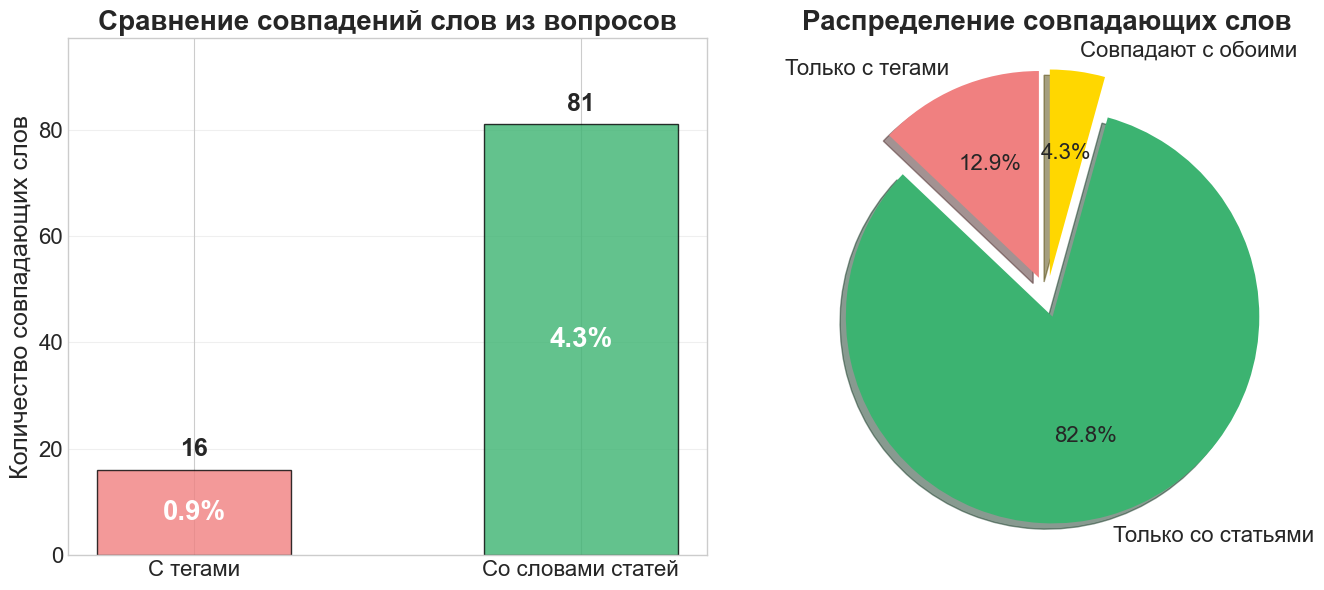

In [25]:
# Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
# Упрощенная версия с основными графиками
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Сравнительная гистограмма
categories = ['С тегами', 'Со словами статей']
overlap_counts = [len(overlap_with_tags), len(overlap_with_articles)]

bars = axes[0].bar(categories, overlap_counts, color=['lightcoral', 'mediumseagreen'], 
                   edgecolor='black', alpha=0.8, width=0.5)
axes[0].set_title('Сравнение совпадений слов из вопросов', fontsize=20, fontweight='bold')
axes[0].set_ylabel('Количество совпадающих слов', fontsize=18)
axes[0].tick_params(axis='both', labelsize=16)
axes[0].set_ylim(0, max(overlap_counts) * 1.2)

for bar, count in zip(bars, overlap_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, count + max(overlap_counts)*0.02,
                f'{count}', ha='center', va='bottom', fontsize=18, fontweight='bold')

# Добавляем процент от общего числа слов
total_words = len(question_words_set)
for bar, count in zip(bars, overlap_counts):
    pct = (count / total_words) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, count/2,
                f'{pct:.1f}%', ha='center', va='center', 
                fontsize=20, color='white', fontweight='bold')

axes[0].grid(True, alpha=0.3, axis='y')

# 2. Визуализация пересечений
# Создаем данные для отображения
labels = ['Уникальные\nслова в\nвопросах', 'Совпадение\nс тегами', 'Совпадение\nсо статьями']
sizes = [total_words - len(overlap_with_tags.union(overlap_with_articles)), 
         len(overlap_with_tags), 
         len(overlap_with_articles)]
colors = ['lightblue', 'lightcoral', 'mediumseagreen']
explode = (0, 0.1, 0.1)

# Убираем дублирование для круговой диаграммы (слова могут совпадать и с тегами, и со статьями)
only_tags = len(overlap_with_tags - overlap_with_articles)
only_articles = len(overlap_with_articles - overlap_with_tags)
both = len(overlap_with_tags & overlap_with_articles)

labels2 = ['Только с тегами', 'Только со статьями', 'Совпадают с обоими']
sizes2 = [only_tags, only_articles, both]
colors2 = ['lightcoral', 'mediumseagreen', 'gold']
explode2 = (0.1, 0.1, 0.1)

# Строим круговую диаграмму
wedges, texts, autotexts = axes[1].pie(sizes2, labels=labels2, colors=colors2,
                                        autopct='%1.1f%%', explode=explode2,
                                        shadow=True, startangle=90)
axes[1].set_title('Распределение совпадающих слов', fontsize=20, fontweight='bold')
plt.setp(autotexts, fontsize=16)
plt.setp(texts, fontsize=16)

plt.tight_layout()
plt.show()

In [21]:
# Корреляция тегов и слов
# Для каждой статьи: выделяем топ-слов и отмечаем встречаемость по тегам
records = []
for _, row in train.iterrows():
    tags = [t.lower() for t in row['tag_list']]
    words = [w for w, _ in Counter(
        [w for w in word_tokenize(clean_text(row['text'])) if w not in stop_words and len(w) > 2]
    ).most_common(20)]
    for t in tags:
        for w in words:
            records.append((t, w))


In [35]:
df_corr = pd.DataFrame(records, columns=['tag', 'word'])
pivot = pd.crosstab(df_corr['tag'], df_corr['word'])

In [36]:
# Корреляция между тегами и словами в статьях
corr_matrix = pivot.corr(method='pearson')
print('Размерность корреляционной матрицы', corr_matrix.shape)

Размерность корреляционной матрицы (1875, 1875)


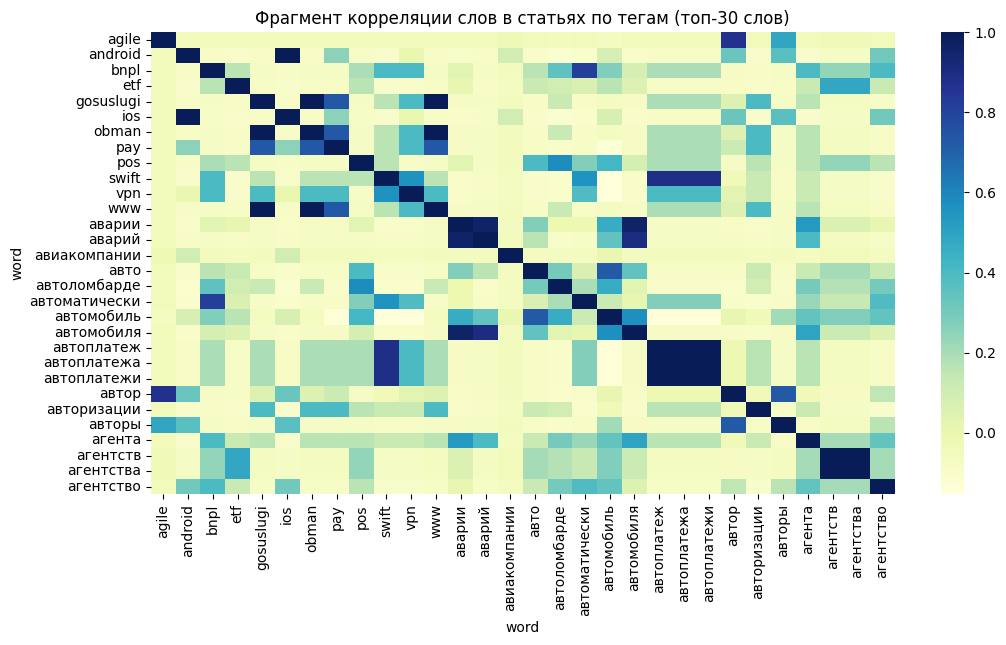

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix.iloc[:30, :30], cmap='YlGnBu')
plt.title('Фрагмент корреляции слов в статьях по тегам (топ-30 слов)')
plt.show()

In [38]:
# Анализ корреляции между тегами и вопросами
tag_question_overlap = {tag: len(set(re.findall(r'\b' + re.escape(tag.lower()) + r'\b', ' '.join(question_words_set)))) for tag in tags_set}
tag_question_overlap = {k: v for k, v in tag_question_overlap.items() if v > 0}
print('Теги, встречающиеся в вопросах')
print(tag_question_overlap)


Теги, встречающиеся в вопросах
{'кредиты': 1, 'переводы': 1, 'долги': 1, 'страховки': 1, 'планирование': 1, 'инвестиции': 1, 'вклады': 1, 'просрочки': 1, 'банки': 1, 'займы': 1, 'акции': 1, 'банкротство': 1, 'форекс': 1, 'облигации': 1, 'осаго': 1, 'технологии': 1}


## Выводы:

1. **В датасете train_data.csv:**
   - 350 объектов;
   - 4 поля: id, аннотация, теги, текст статьи.
   
   Обнаружено 4 пустых значения в поле аннотации, однако это не серьезно, т.к. текст аннотации не полезен в дальнейшем использовании. Средняя длина статей составляет 9027 символов или 1307 слов.

2. **В датасете questions.csv:**:
   - 500 объектов;
   - 2 поля: id, текст вопроса.
   
   Обнаружено 2 дубликата, которые были удалены. 
   Средняя длина вопроса составляет 10 слов.

Пересечение слов вопросов с тегами гораздо меньше, чем с контентом статей, что делает теги бесполезными для прямого поиска. Также обнаружен дисбаланс тегов: топ-3 тега присутствуют для 71% всех статей. 
Маркдаун-разметка присутствует практически во всех статьях (99.7%), что позволит по заголовкам построить разбиение на чанки.